In [14]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

custom_map = [
    "FFSF",
    "FFFF",
    "FFFF",
    "FGFF"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=True
)



In [16]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995

In [17]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

num_states = env.observation_space.n
num_actions = env.action_space.n

Q = np.zeros((num_states, num_actions))



# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):
    """
    Selects an action using epsilon-greedy strategy.
    """
    # Write your code here

def epsilon_greedy_action(state, epsilon):
    """
    Select an action using epsilon-greedy strategy.
    """

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    max_q = np.max(Q[state])

    # Select randomly among equally good actions
    best_actions = np.flatnonzero(Q[state] == max_q)

    return np.random.choice(best_actions)


In [18]:
# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

# Write your code here

episode_rewards = []

for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Select initial action using epsilon-greedy policy
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        # Check whether episode has ended
        done = terminated or truncated

        if done:

            # Terminal state has no future Q-value
            target = reward

            # SARSA update
            Q[state, action] += alpha * (
                target - Q[state, action]
            )

            break

        # Select next action using the same epsilon-greedy policy
        next_action = epsilon_greedy_action(
            next_state,
            epsilon
        )

        # SARSA target
        target = reward + gamma * Q[next_state, next_action]

        # SARSA update
        Q[state, action] += alpha * (
            target - Q[state, action]
        )

        # Move to next state-action pair
        state = next_state
        action = next_action

    # Store reward for this episode
    episode_rewards.append(total_reward)

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [19]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [20]:
# -------------------------------------------------
# Output
# -------------------------------------------------


print("\nFinal Q-table:")
print(np.round(Q, 3))

# Calculate state values from Q-table
state_values = np.max(Q, axis=1)

# Derive optimal policy from Q-table
learned_policy = np.argmax(Q, axis=1)

print_value_function(state_values)

print_policy(learned_policy)

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    round(average_reward, 3)
)



Final Q-table:
[[0.877 0.88  0.893 0.875]
 [0.886 0.874 0.877 0.873]
 [0.887 0.873 0.873 0.867]
 [0.87  0.86  0.86  0.86 ]
 [0.901 0.928 0.899 0.888]
 [0.891 0.921 0.889 0.887]
 [0.894 0.911 0.891 0.884]
 [0.875 0.896 0.885 0.873]
 [0.933 0.953 0.937 0.938]
 [0.965 0.939 0.941 0.924]
 [0.924 0.939 0.912 0.916]
 [0.902 0.919 0.896 0.903]
 [0.962 0.983 0.962 0.972]
 [0.    0.    0.    0.   ]
 [0.963 0.931 0.927 0.93 ]
 [0.914 0.933 0.909 0.908]]

Estimated State-Value Function:
[[0.893 0.886 0.887 0.87 ]
 [0.928 0.921 0.911 0.896]
 [0.953 0.965 0.939 0.919]
 [0.983 0.    0.963 0.933]]

Learned Policy:
[['R' 'L' 'L' 'L']
 ['D' 'D' 'D' 'D']
 ['D' 'L' 'D' 'D']
 ['D' 'L' 'L' 'D']]

Average reward over last 1000 episodes: 1.0


Name:Ranjan Kumar G
Reg No:212223240138


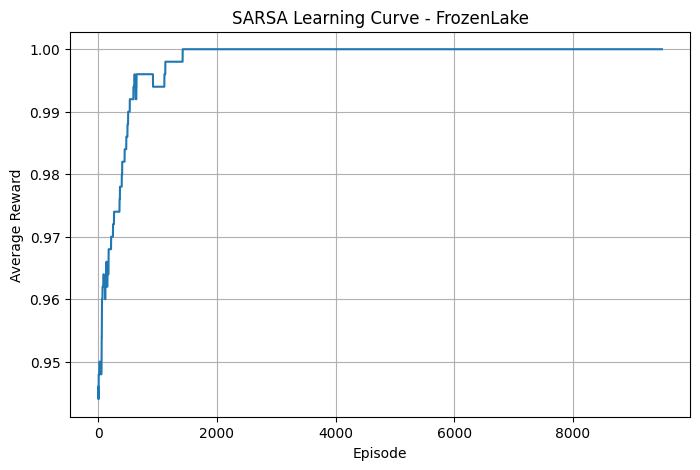

In [21]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------
print("Name:Ranjan Kumar G")
print("Reg No:212223240138")
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()